#Load Data

In [12]:
import pandas as pd

df = pd.read_csv("sample_data/StudentsPerformance.csv")
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


##Data Quality

In [22]:
df.dtypes

,0
gender,object
race/ethnicity,object
parental level of education,object
lunch,object
test preparation course,object
math score,float64
reading score,int64
writing score,int64


In [13]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


,0
gender,0
race/ethnicity,0
parental level of education,0
lunch,0
test preparation course,0
math score,0
reading score,0
writing score,0


##Missing Values


In [25]:
df.isna()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...
995,False,False,False,False,False,False,False,False
996,False,False,False,False,False,False,False,False
997,False,False,False,False,False,False,False,False
998,False,False,False,False,False,False,False,False


In [24]:
df.isna().sum()

,0
gender,0
race/ethnicity,0
parental level of education,0
lunch,0
test preparation course,0
math score,0
reading score,0
writing score,0


In [26]:
df.loc[2, 'math score'] = None

df['math score'] = df['math score'].fillna(df['math score'].mean())

##Outliers (IQR)

In [17]:
Q1 = df['math score'].quantile(0.25)
Q3 = df['math score'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df = df[(df['math score'] >= lower) & (df['math score'] <= upper)]

In [30]:
df_no_outliers = df[(df['math score'] >= lower) & (df['math score'] <= upper)]
print('df with outliers: ',df.shape)
print('df without outliers: ',df_no_outliers.shape)

df with outliers:  (992, 8)
df without outliers:  (0, 8)


#####capping Outliers

In [31]:
Q1 = df['math score'].quantile(0.25)
Q3 = df['math score'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df['math score'] = df['math score'].clip(lower, upper)

#Normalization

####Min-Max

In [18]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
df[['math score']] = scaler.fit_transform(df[['math score']])

####Z-score

In [19]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df[['math score']] = scaler.fit_transform(df[['math score']])

####PCA

<Axes: >

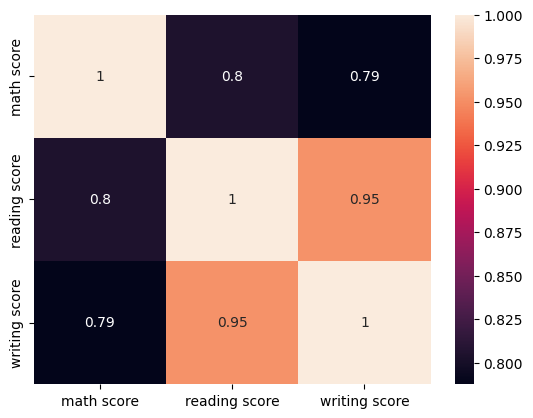

In [20]:
import seaborn as sns

sns.heatmap(df[['math score','reading score','writing score']].corr(), annot=True)

In [21]:
from sklearn.decomposition import PCA

features = df[['math score','reading score','writing score']]

pca = PCA(n_components=2)
df_pca = pca.fit_transform(features)

df_pca[:5]

array([[  5.82522565,  -2.06649192],
       [ 28.36700003,   1.1816503 ],
       [ 35.42314158,   1.31039912],
       [-26.23912919,   7.90426259],
       [ 10.71189532,   1.56615589]])

In [35]:
pca_df = pd.DataFrame(principal_components, columns=['PC1', 'PC2'])
pca_df.head()

,PC1,PC2
0,0.539219,0.092647
1,1.726942,-0.929731
2,2.035975,-1.343556
3,-2.223591,-0.103893
4,0.979679,0.143553


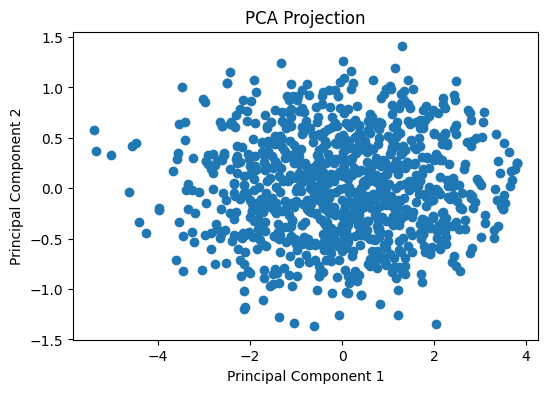

In [33]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

features = df[['math score', 'reading score', 'writing score']]

scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

pca = PCA(n_components=2)
principal_components = pca.fit_transform(scaled_features)

plt.figure(figsize=(6,4))
plt.scatter(principal_components[:,0], principal_components[:,1])
plt.title("PCA Projection")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()